In [2]:
!pip install nltk scikit-learn seaborn joblib


In [3]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
df = pd.read_csv('imdb_reviews1.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\\S+', '', text)

    text = re.sub(r'\\d+', '', text)

    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    words = text.split()

    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

In [8]:
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,oneoftheotherreviewershasmentionedthatafterwat...
1,A wonderful little production. <br /><br />The...,positive,awonderfullittleproductionbrbrthefilmingtechni...
2,I thought this was a wonderful way to spend ti...,positive,ithoughtthiswasawonderfulwaytospendtimeonatooh...
3,Basically there's a family where a little boy ...,negative,basicallytheresafamilywherealittleboyjakethink...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,pettermatteisloveinthetimeofmoneyisavisuallyst...


In [9]:
label_mapping = {
    'negative': 0,
    'positive': 1
}

df['sentiment'] = df['sentiment'].map(label_mapping)

In [10]:
X = df['clean_review']

y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [12]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [14]:
y_pred = model.predict(X_test_tfidf)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.4971


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.66      4961
           1       1.00      0.00      0.00      5039

    accuracy                           0.50     10000
   macro avg       0.75      0.50      0.33     10000
weighted avg       0.75      0.50      0.33     10000



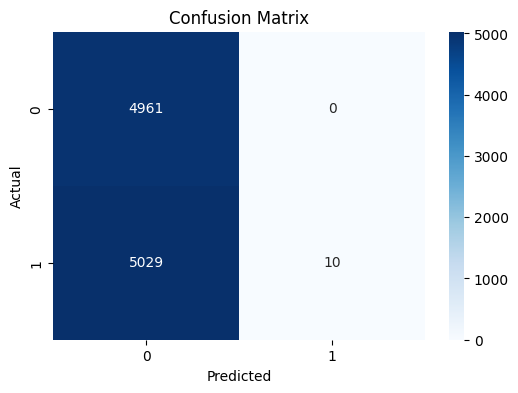

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [18]:
sample_reviews = [
    "This product is amazing",
    "Worst purchase ever"
]

cleaned_reviews = [clean_text(review) for review in sample_reviews]

review_vectors = vectorizer.transform(cleaned_reviews)

predictions = model.predict(review_vectors)

for review, prediction in zip(sample_reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print(review, "->", sentiment)

This product is amazing -> Negative
Worst purchase ever -> Negative


In [28]:
import joblib

joblib.dump(model, 'sentiment_model.pkl')

joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']